In [24]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
pd.set_option('display.max_columns', None)
%matplotlib inline
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/heart.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("Dataset shape:", df.shape)


Dataset shape: (302, 14)


In [6]:
print("Columns and data types:")
print(df.dtypes)


Columns and data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [7]:
print("\nDataFrame info:")
df.info()

print("\nDataFrame describe:")
display(df.describe())



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB

DataFrame describe:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Missing values per column:


,missing_count,missing_pct
age,0,0.00%
sex,0,0.00%
cp,0,0.00%
trestbps,0,0.00%
chol,0,0.00%
fbs,0,0.00%
restecg,0,0.00%
thalach,0,0.00%
exang,0,0.00%
oldpeak,0,0.00%


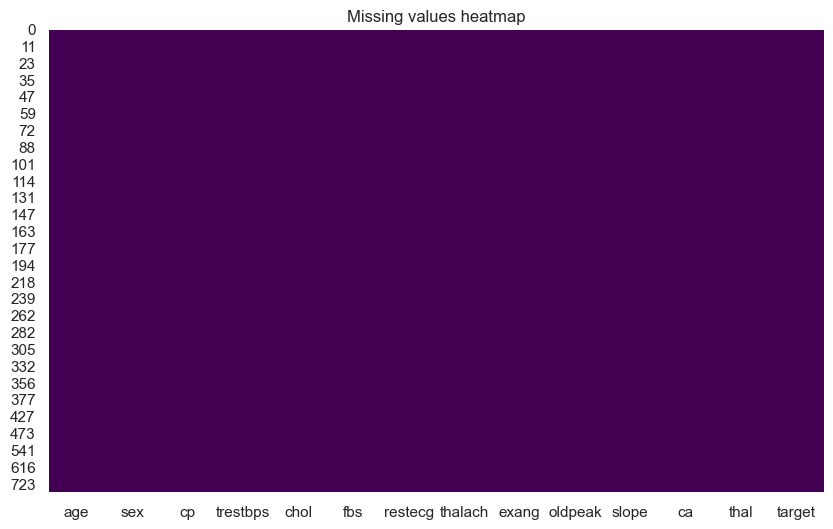

In [8]:
missing = df.isna().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

print("\nMissing values per column:")
display(missing_df.style.format({"missing_pct": "{:.2f}%"}))

plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing values heatmap")
plt.show()


In [9]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


Duplicate rows: 0
No duplicate rows found.


In [10]:
import os
os.makedirs('../outputs/plots', exist_ok=True)
print('Created outputs/plots directory if needed.')

Created outputs/plots directory if needed.


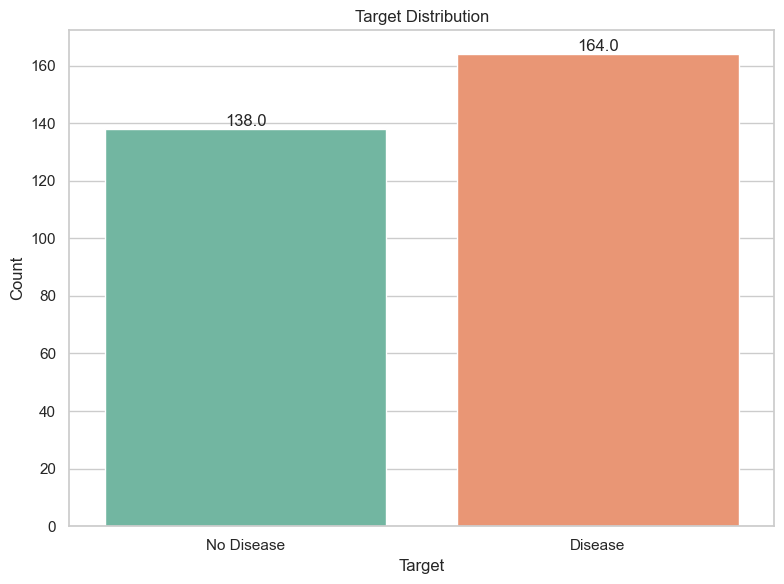

In [11]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='target', data=df, palette='Set2')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_title('Target Distribution')
ax.set_xlabel('Target')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/plots/target_countplot.png')
plt.show()

In [12]:
disease_rate = df['target'].mean() * 100
print(f'Disease rate: {disease_rate:.2f}%')

Disease rate: 54.30%


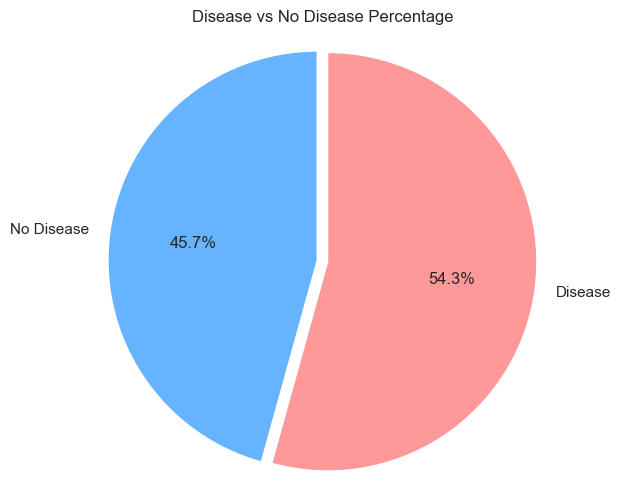

In [13]:
labels = ['No Disease', 'Disease']
sizes = df['target'].value_counts().sort_index().values
colors = ['#66b3ff', '#ff9999']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.05))
plt.title('Disease vs No Disease Percentage')
plt.axis('equal')
plt.savefig('../outputs/plots/target_pie_chart.png')
plt.show()

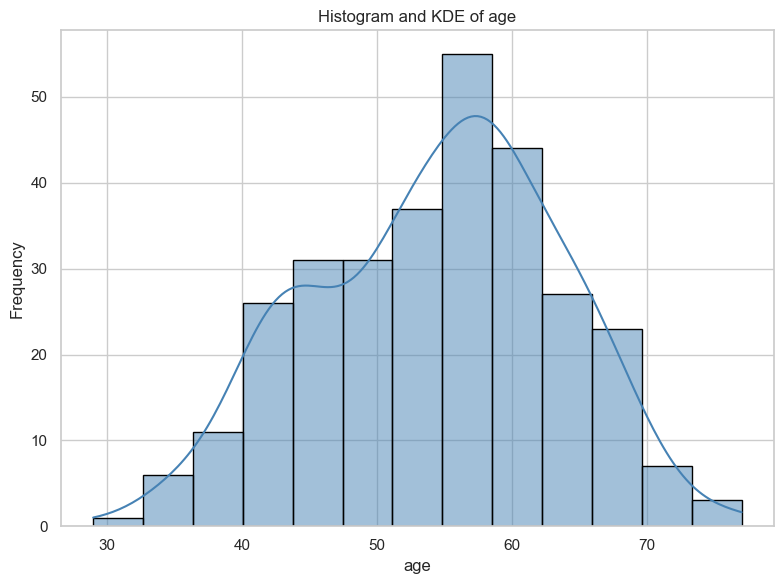

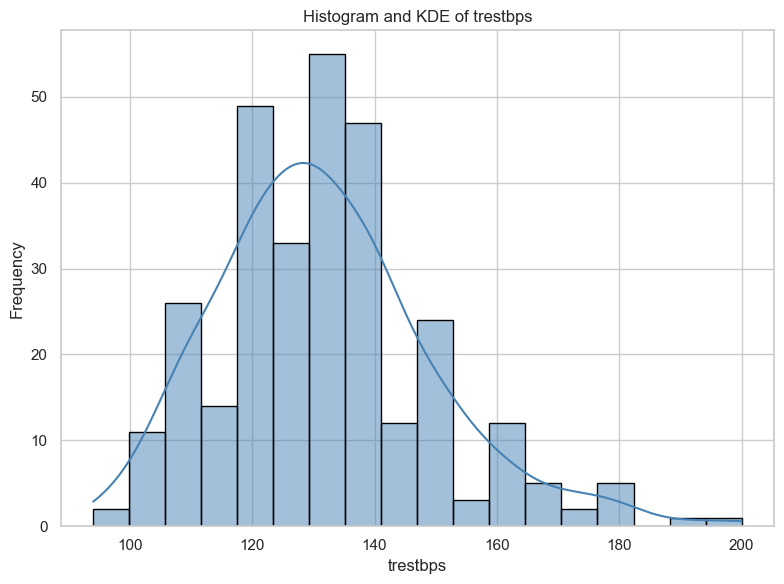

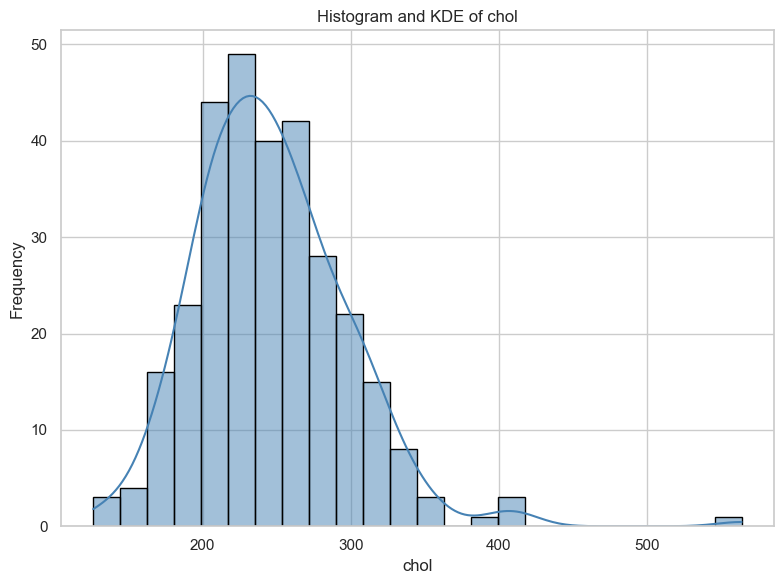

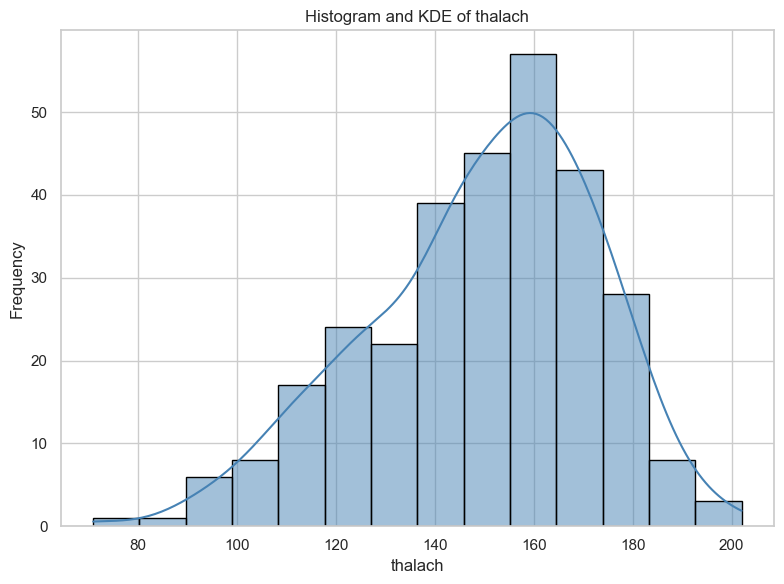

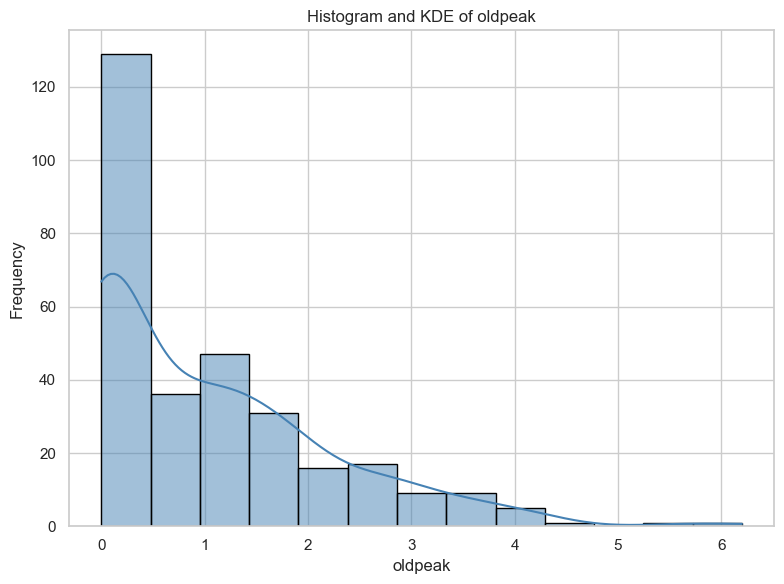

In [14]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for feature in numeric_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[feature], kde=True, color='steelblue', edgecolor='black')
    plt.title(f'Histogram and KDE of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'../outputs/plots/{feature}_hist_kde.png')
    plt.show()

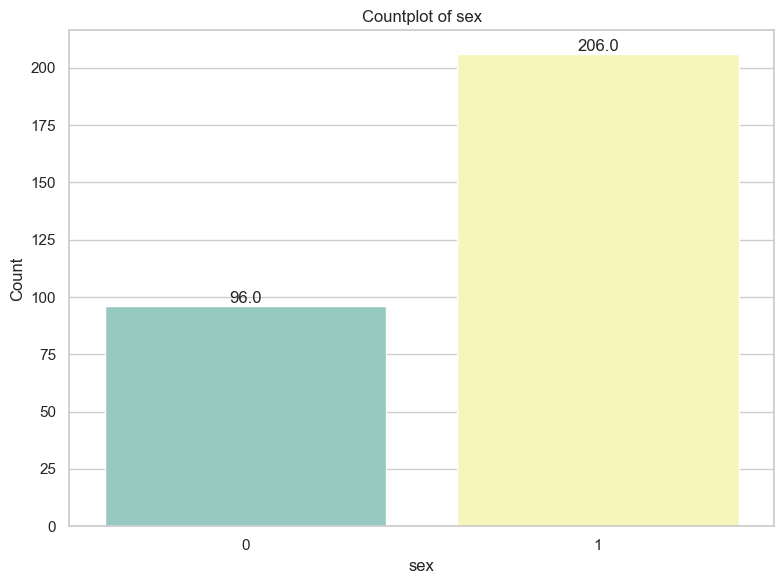

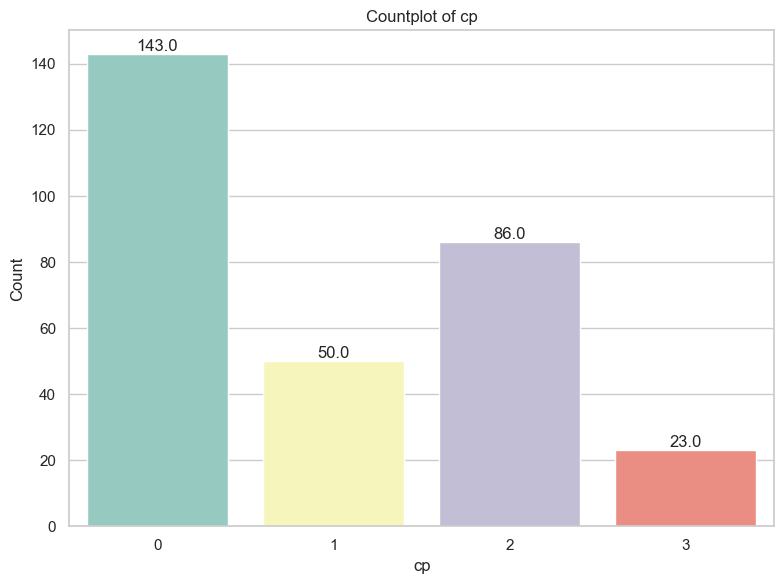

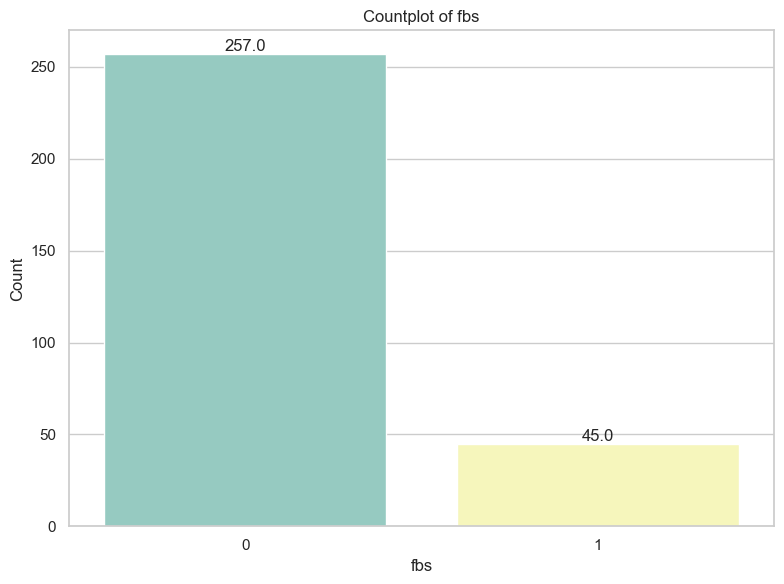

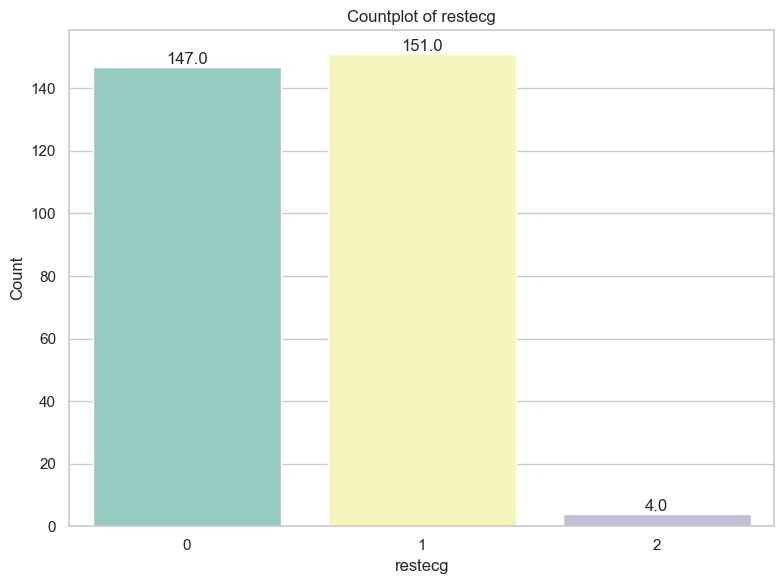

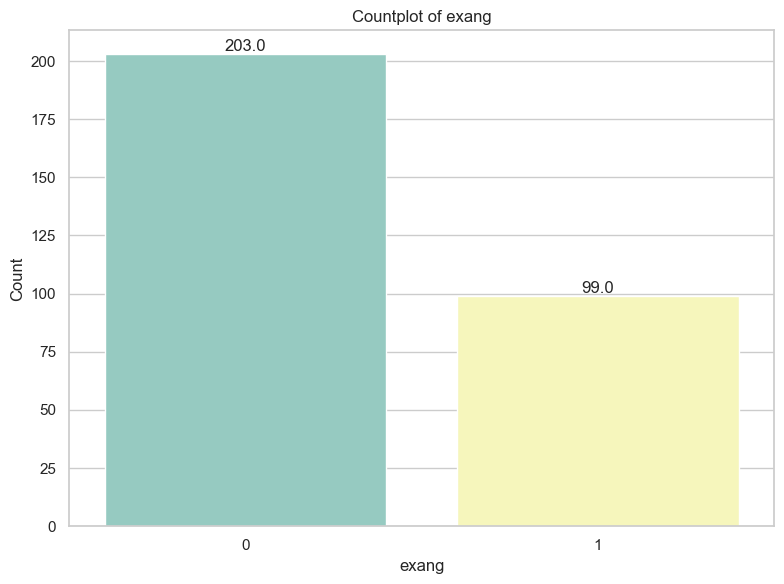

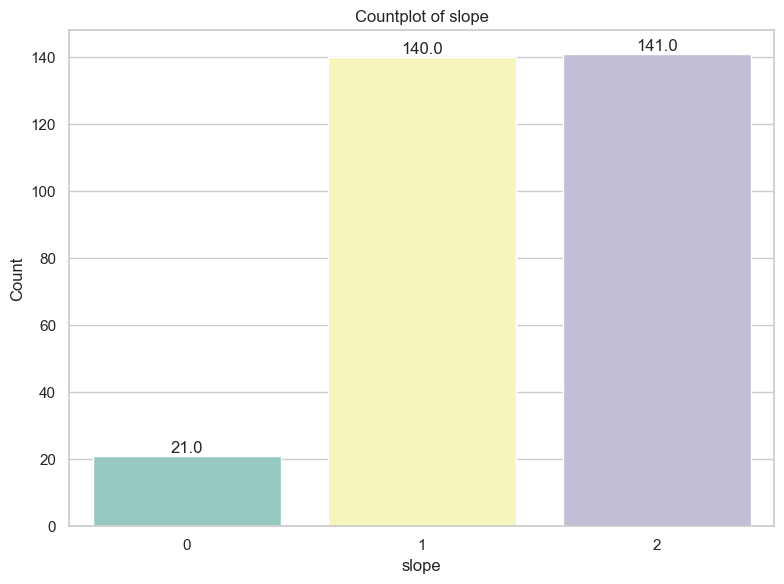

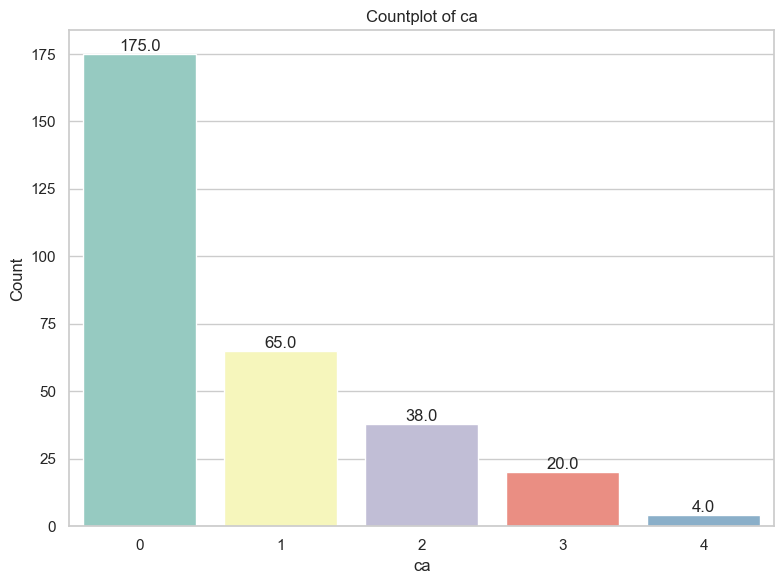

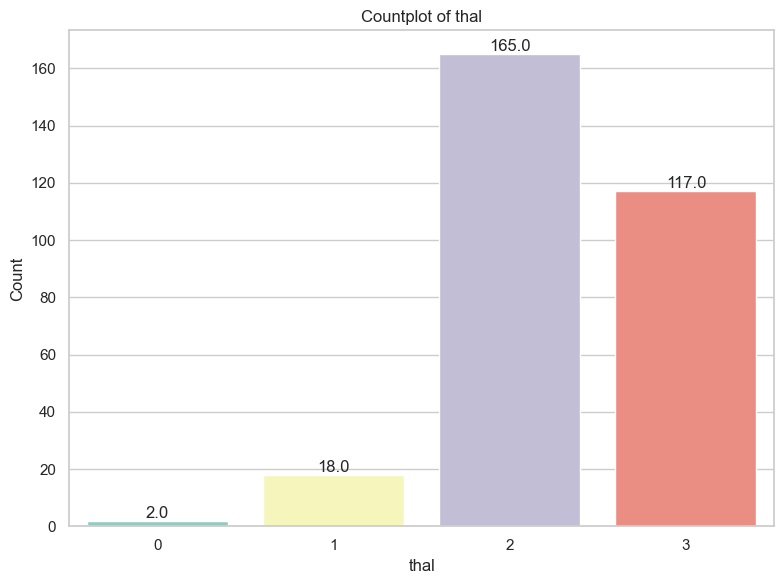

In [15]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for feature in cat_features:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=feature, data=df, palette='Set3')
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom')
    plt.title(f'Countplot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(f'../outputs/plots/{feature}_countplot.png')
    plt.show()

In [16]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for feature in numeric_features:
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    std_val = df[feature].std()
    min_val = df[feature].min()
    max_val = df[feature].max()
    print(f"{feature} -> mean: {mean_val:.2f}, median: {median_val:.2f}, std: {std_val:.2f}, min: {min_val:.2f}, max: {max_val:.2f}")

age -> mean: 54.42, median: 55.50, std: 9.05, min: 29.00, max: 77.00
trestbps -> mean: 131.60, median: 130.00, std: 17.56, min: 94.00, max: 200.00
chol -> mean: 246.50, median: 240.50, std: 51.75, min: 126.00, max: 564.00
thalach -> mean: 149.57, median: 152.50, std: 22.90, min: 71.00, max: 202.00
oldpeak -> mean: 1.04, median: 0.80, std: 1.16, min: 0.00, max: 6.20


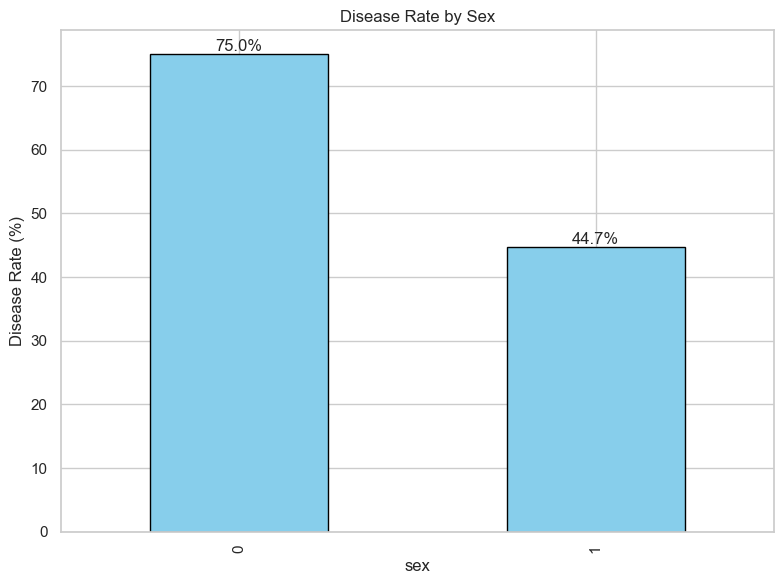

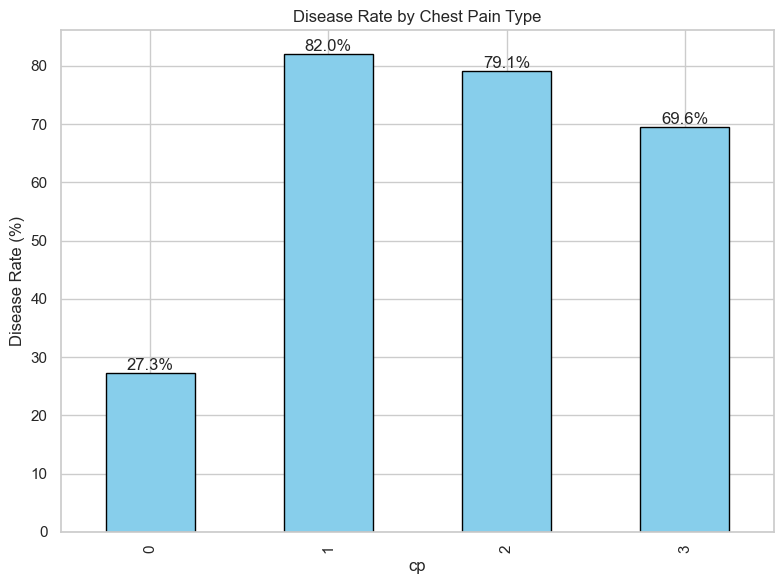

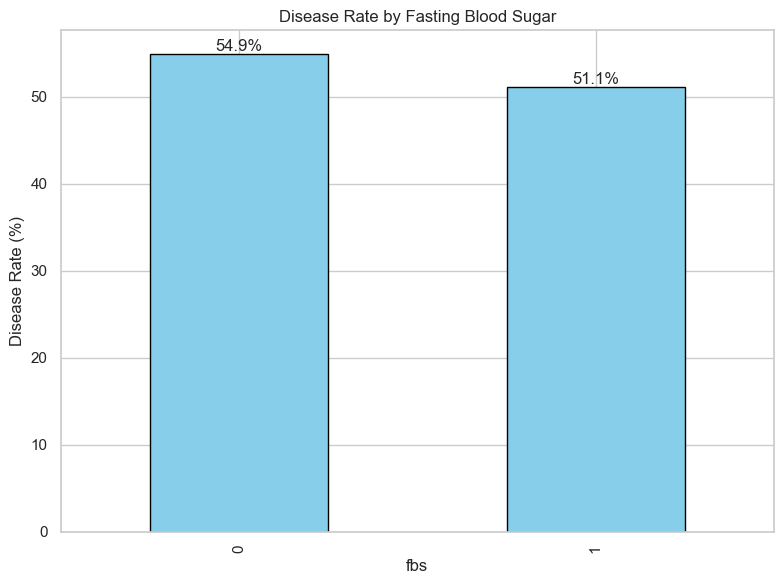

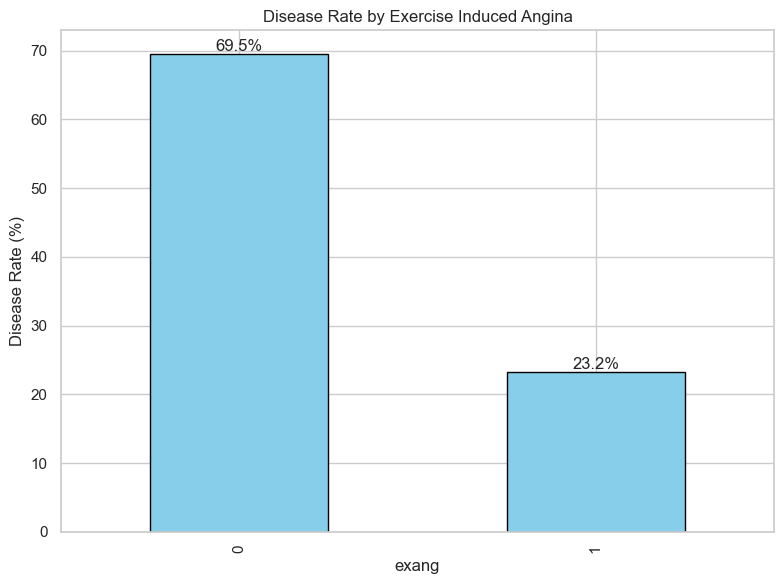

In [17]:
# Grouped bar charts: disease rate by categorical features
for feature, title in [
    ('sex', 'Disease Rate by Sex'),
    ('cp', 'Disease Rate by Chest Pain Type'),
    ('fbs', 'Disease Rate by Fasting Blood Sugar'),
    ('exang', 'Disease Rate by Exercise Induced Angina')
]:
    grouped = df.groupby(feature)['target'].mean() * 100
    plt.figure(figsize=(8, 6))
    ax = grouped.plot(kind='bar', color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel('Disease Rate (%)')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(f'../outputs/plots/{feature}_disease_rate.png')
    plt.show()


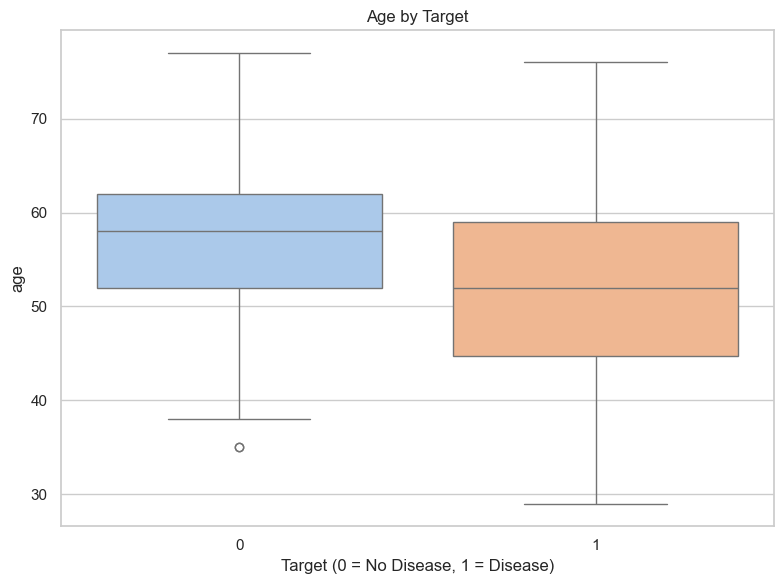

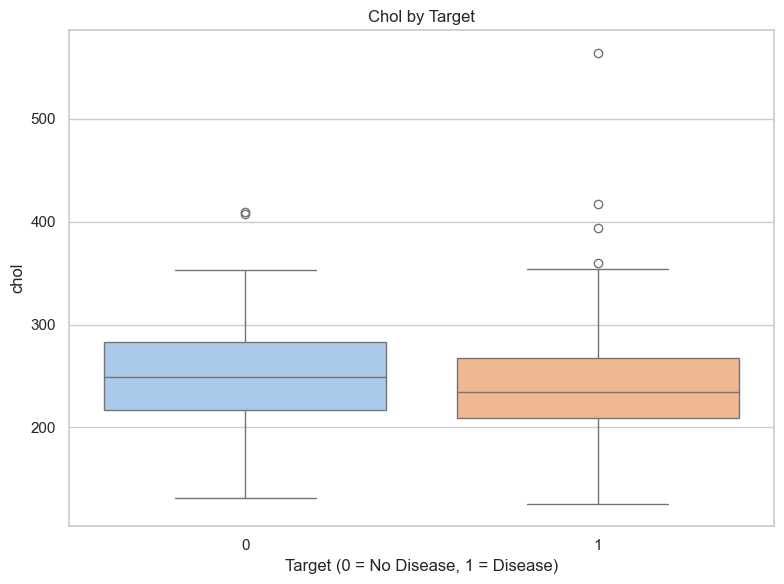

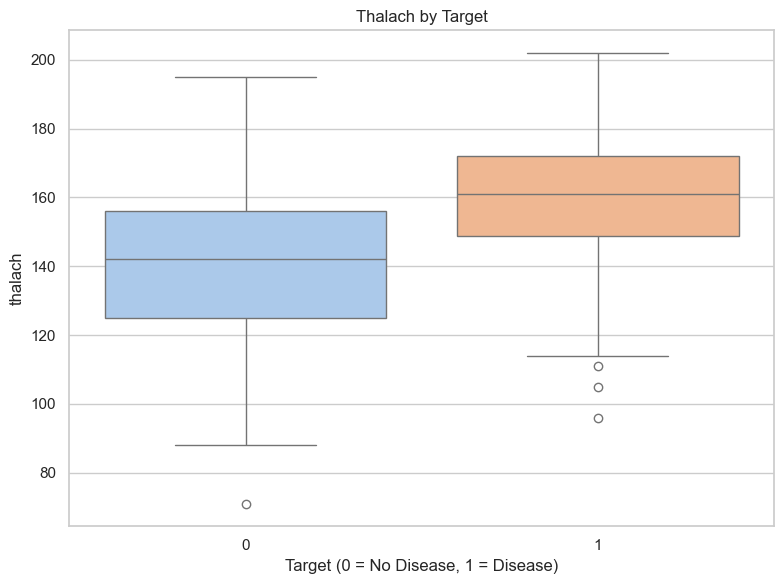

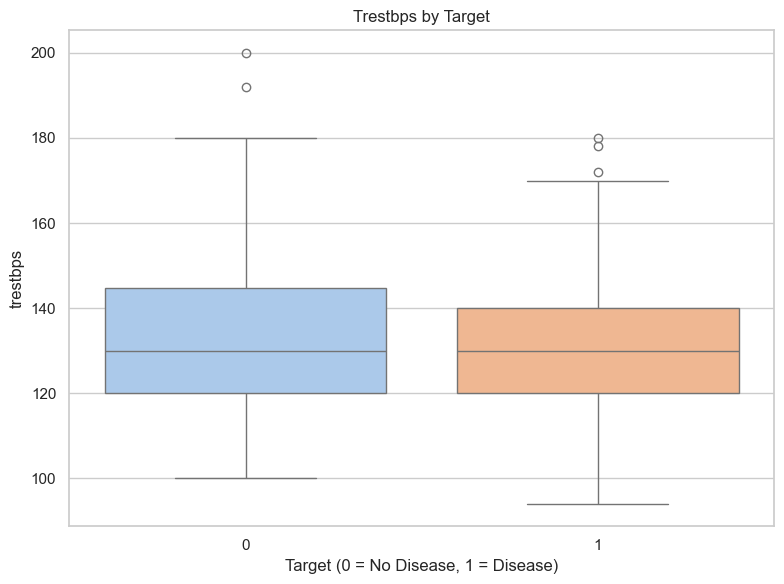

In [18]:
# Boxplots for numeric features vs target
for feature in ['age', 'chol', 'thalach', 'trestbps']:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='target', y=feature, data=df, palette='pastel')
    plt.title(f'{feature.capitalize()} by Target')
    plt.xlabel('Target (0 = No Disease, 1 = Disease)')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(f'../outputs/plots/{feature}_by_target_boxplot.png')
    plt.show()


In [19]:
# Disease rate % table for categorical features
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
summary_rows = []
for feature in cat_features:
    grouped = df.groupby(feature)['target'].mean() * 100
    for category, rate in grouped.items():
        summary_rows.append({
            'feature': feature,
            'category': category,
            'disease_rate_pct': round(rate, 2)
        })
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['feature', 'category']).reset_index(drop=True)
print('Disease rate % by categorical feature:')
display(summary_df)

Disease rate % by categorical feature:


,feature,category,disease_rate_pct
0,ca,0,74.29
1,ca,1,32.31
2,ca,2,18.42
3,ca,3,15.00
4,ca,4,75.00
5,cp,0,27.27
6,cp,1,82.00
7,cp,2,79.07
8,cp,3,69.57
9,exang,0,69.46


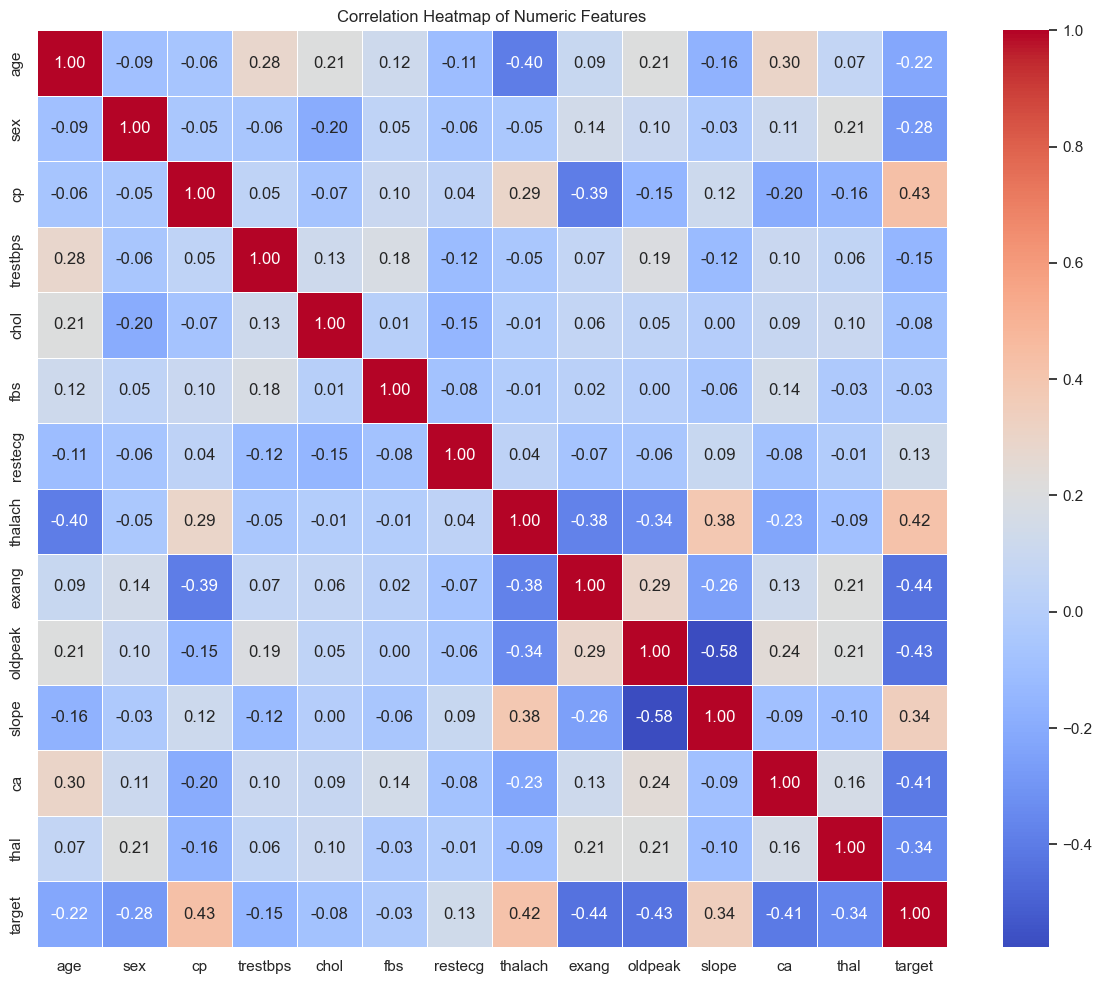

Top 5 features most correlated with target:
exang      0.435601
cp         0.432080
oldpeak    0.429146
thalach    0.419955
ca         0.408992
Name: target, dtype: float64


In [20]:
# Correlation heatmap of numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap.png')
plt.show()

# Top 5 features most correlated with target
target_corr = corr['target'].abs().sort_values(ascending=False).drop('target')
print('Top 5 features most correlated with target:')
print(target_corr.head(5))

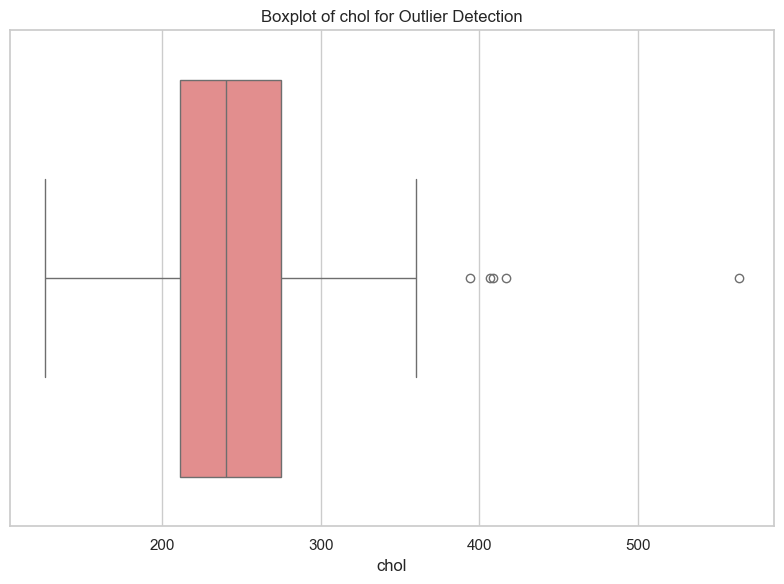

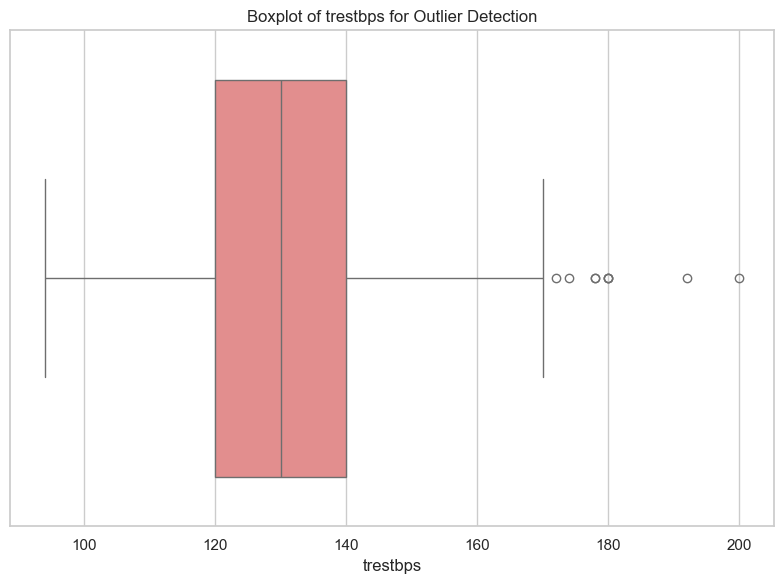

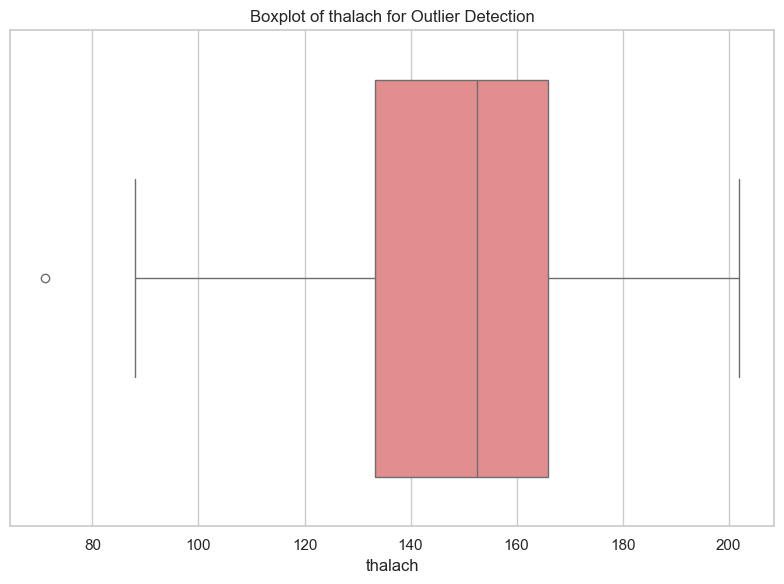

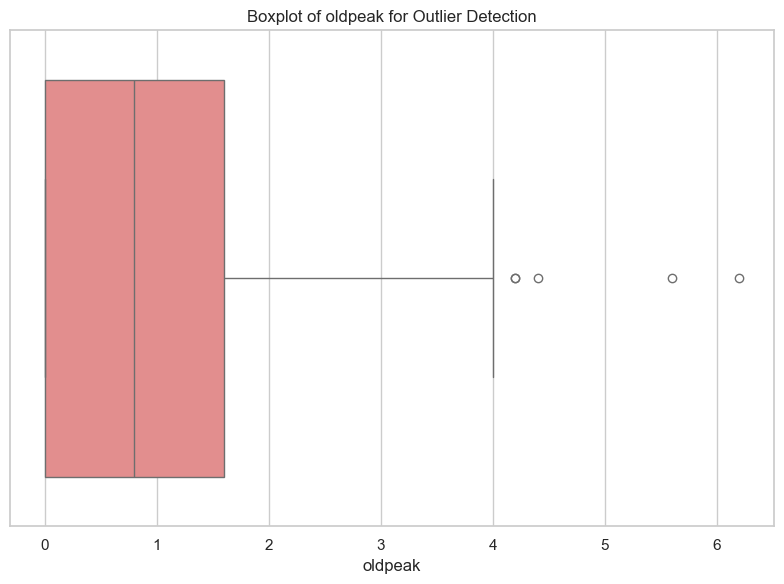

In [21]:
# Boxplots for outlier detection
for feature in ['chol', 'trestbps', 'thalach', 'oldpeak']:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[feature], color='lightcoral')
    plt.title(f'Boxplot of {feature} for Outlier Detection')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.savefig(f'../outputs/plots/{feature}_outlier_boxplot.png')
    plt.show()

In [22]:
# Count of outliers using the IQR method
outlier_counts = {}
for feature in ['chol', 'trestbps', 'thalach', 'oldpeak']:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_counts[feature] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['outlier_count'])
print('Outlier counts by feature:')
display(outlier_df)


Outlier counts by feature:


,outlier_count
chol,5
trestbps,9
thalach,1
oldpeak,5
